<a href="https://colab.research.google.com/github/ShubhGuPTA-cmd/ML-experiments/blob/main/exp_%5Blinear_regression%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving insurance.csv.zip to insurance.csv.zip


In [ ]:
import io
import zipfile
import pandas as pd

# Get uploaded ZIP file
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

# Open ZIP file
with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:
    print("Files inside ZIP:")
    print(zip_ref.namelist())

Uploaded file: insurance.csv.zip
Files inside ZIP:
['insurance.csv']


In [ ]:
with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:

    # Get the CSV filename
    csv_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith('.csv')
    ]

    print("CSV files found:", csv_files)

    # Read the first CSV
    with zip_ref.open(csv_files[0]) as csv_file:
        df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

CSV files found: ['insurance.csv']
Dataset loaded successfully!
Shape: (1338, 7)


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
print("Sex values:")
print(df['sex'].value_counts())

print("\nSmoker values:")
print(df['smoker'].value_counts())

print("\nRegion values:")
print(df['region'].value_counts())

Sex values:
sex
male      675
female    662
Name: count, dtype: int64

Smoker values:
smoker
no     1063
yes     274
Name: count, dtype: int64

Region values:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


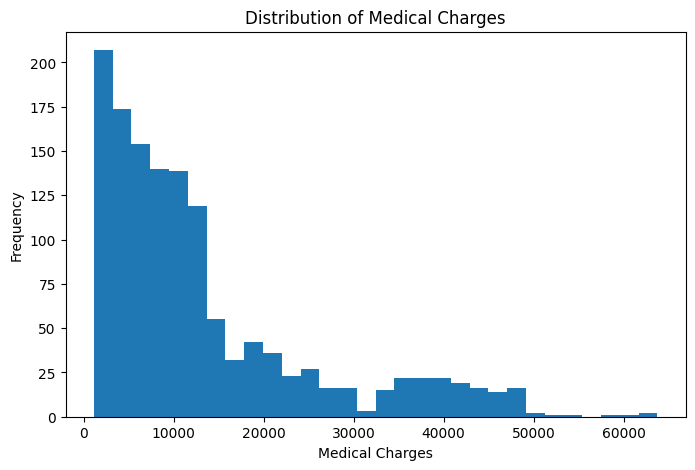

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['charges'], bins=30)

plt.xlabel('Medical Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Charges')

plt.show()

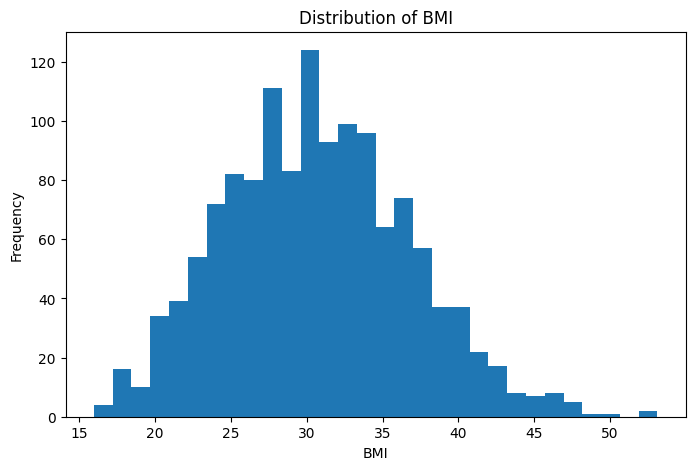

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['bmi'], bins=30)

plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Distribution of BMI')

plt.show()

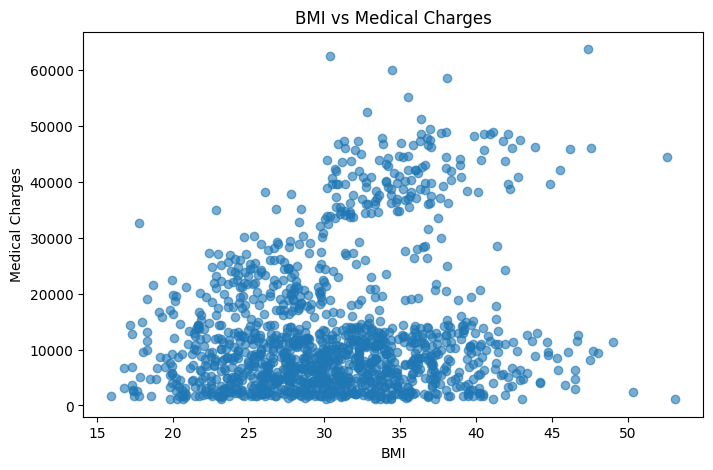

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['bmi'],
    df['charges'],
    alpha=0.6
)

plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.title('BMI vs Medical Charges')

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


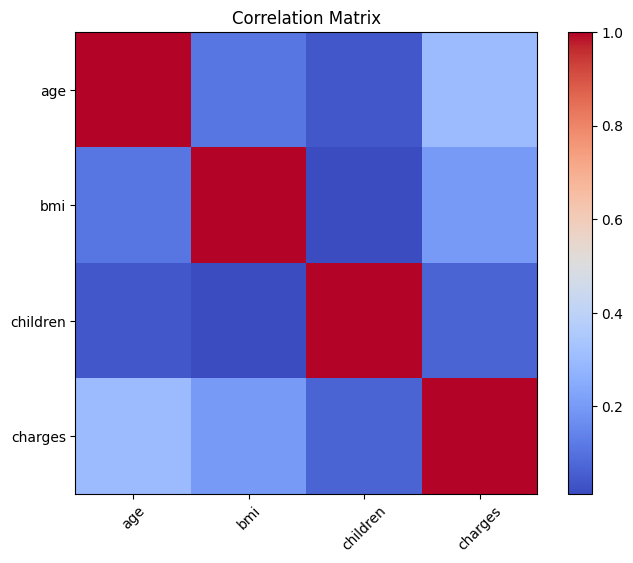

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap='coolwarm',
    interpolation='none'
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Matrix')

plt.show()

In [ ]:
X = df[['bmi']]
y = df['charges']

print("Input feature:", X.columns.tolist())
print("Target variable:", y.name)

Input feature: ['bmi']
Target variable: charges


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 802
Validation samples: 267
Testing samples: 268


In [ ]:
degrees = range(1, 11)

results = []

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # Training metrics
    train_mse = mean_squared_error(y_train, train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    # Validation metrics
    val_mse = mean_squared_error(y_val, val_pred)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    # Testing metrics
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append([
        degree,
        train_mse,
        train_rmse,
        train_mae,
        train_r2,
        val_mse,
        val_rmse,
        val_mae,
        val_r2,
        test_mse,
        test_rmse,
        test_mae,
        test_r2
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Degree',

        'Train_MSE',
        'Train_RMSE',
        'Train_MAE',
        'Train_R2',

        'Validation_MSE',
        'Validation_RMSE',
        'Validation_MAE',
        'Validation_R2',

        'Test_MSE',
        'Test_RMSE',
        'Test_MAE',
        'Test_R2'
    ]
)

results_df.round(4)

,Degree,Train_MSE,Train_RMSE,Train_MAE,Train_R2,Validation_MSE,Validation_RMSE,Validation_MAE,Validation_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2
0,1,1.309553e+08,11443.5701,8839.8796,0.0217,1.629820e+08,12766.4406,9571.3693,0.0540,1.504366e+08,12265.2609,9186.7181,0.0505
1,2,1.297309e+08,11389.9466,8818.5196,0.0309,1.695570e+08,13021.4038,9760.8891,0.0159,1.506107e+08,12272.3564,9189.6946,0.0494
2,3,1.291953e+08,11366.4117,8829.3692,0.0349,1.733630e+08,13166.7373,9819.8964,-0.0062,1.485001e+08,12186.0618,9137.4242,0.0627
3,4,1.291495e+08,11364.3950,8824.5657,0.0352,1.742520e+08,13200.4536,9824.6961,-0.0114,1.484113e+08,12182.4186,9131.8562,0.0632
4,5,1.289285e+08,11354.6681,8812.7513,0.0369,1.740698e+08,13193.5504,9801.6004,-0.0103,1.483663e+08,12180.5688,9113.0091,0.0635
5,6,1.289254e+08,11354.5343,8811.7961,0.0369,1.742755e+08,13201.3452,9802.7851,-0.0115,1.484040e+08,12182.1169,9118.5606,0.0633
6,7,1.289096e+08,11353.8362,8811.2332,0.0370,1.738664e+08,13185.8403,9795.3306,-0.0092,1.484003e+08,12181.9657,9111.3277,0.0633
7,8,1.288763e+08,11352.3698,8806.3320,0.0373,1.733565e+08,13166.4927,9780.7566,-0.0062,1.485092e+08,12186.4331,9109.6599,0.0626
8,9,1.288556e+08,11351.4564,8798.9645,0.0374,1.728996e+08,13149.1276,9768.1954,-0.0035,1.486913e+08,12193.9033,9115.9232,0.0615
9,10,1.288706e+08,11352.1199,8792.9952,0.0373,1.725844e+08,13137.1386,9763.5081,-0.0017,1.488594e+08,12200.7946,9130.2609,0.0604


In [ ]:
best_index = results_df['Validation_RMSE'].idxmin()

best_row = results_df.loc[best_index]

best_degree = int(best_row['Degree'])

print("Optimal Polynomial Degree:", best_degree)
print("Validation MSE:", best_row['Validation_MSE'])
print("Validation RMSE:", best_row['Validation_RMSE'])
print("Validation MAE:", best_row['Validation_MAE'])
print("Validation R²:", best_row['Validation_R2'])

Optimal Polynomial Degree: 1
Validation MSE: 162982004.7030925
Validation RMSE: 12766.440565133747
Validation MAE: 9571.36929257766
Validation R²: 0.05402238471007759


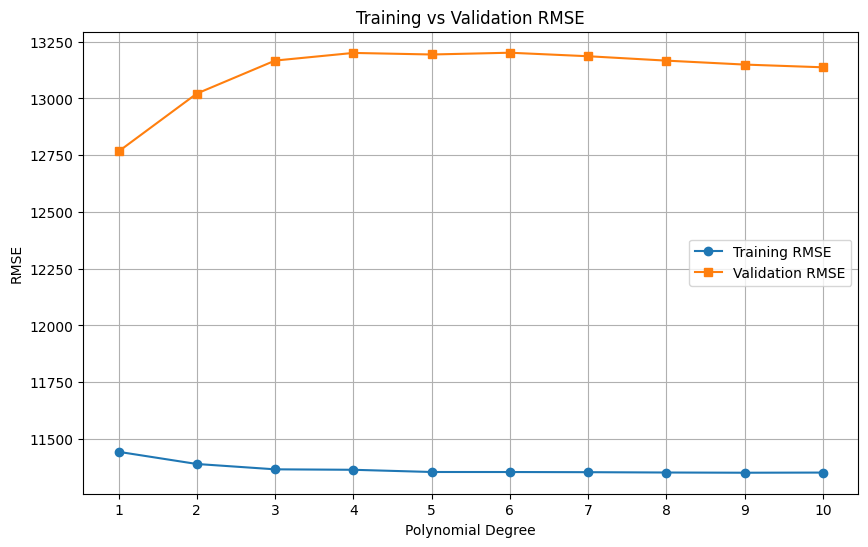

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_RMSE'],
    marker='o',
    label='Training RMSE'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_RMSE'],
    marker='s',
    label='Validation RMSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')

plt.title('Training vs Validation RMSE')

plt.xticks(range(1, 11))

plt.legend()
plt.grid(True)

plt.show()

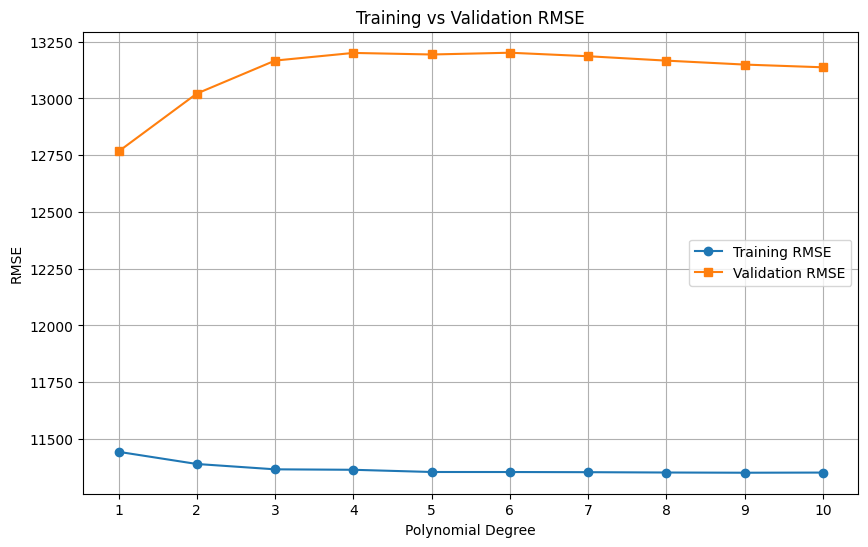

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_RMSE'],
    marker='o',
    label='Training RMSE'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_RMSE'],
    marker='s',
    label='Validation RMSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Training vs Validation RMSE')

plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()

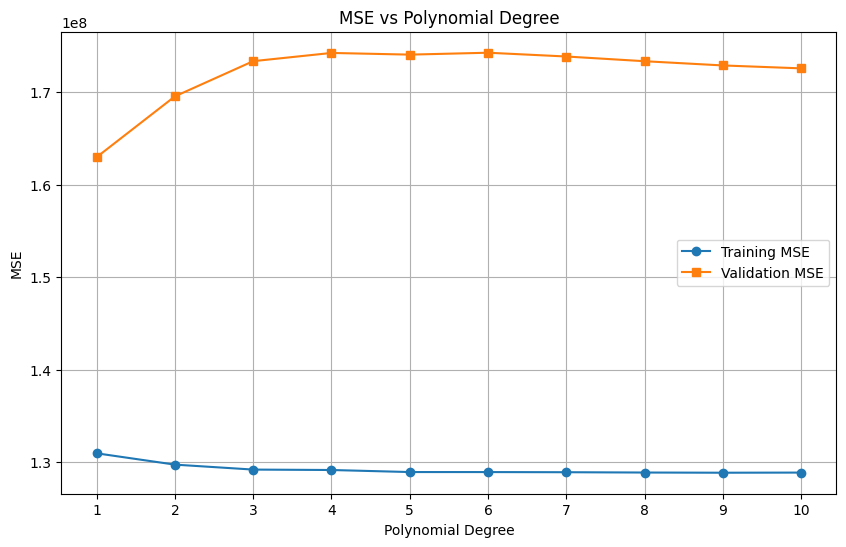

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_MSE'],
    marker='o',
    label='Training MSE'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_MSE'],
    marker='s',
    label='Validation MSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')

plt.title('MSE vs Polynomial Degree')

plt.xticks(range(1, 11))

plt.legend()
plt.grid(True)

plt.show()

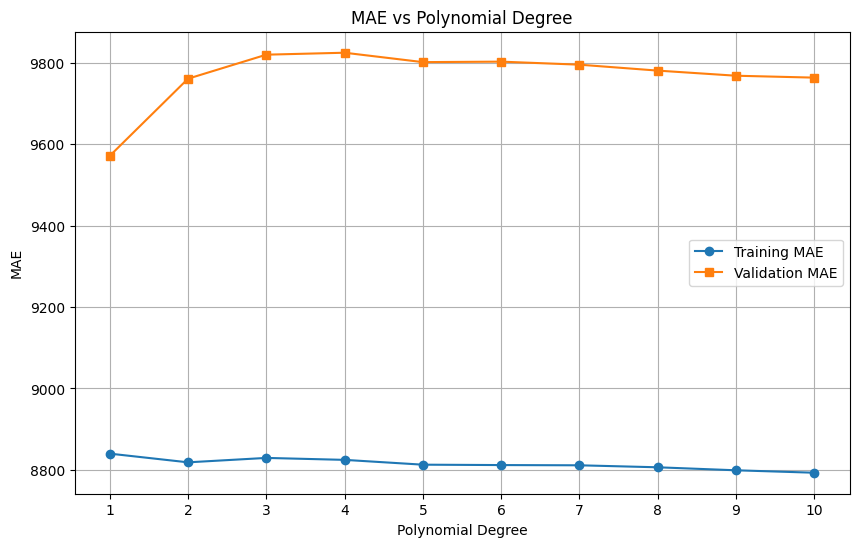

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_MAE'],
    marker='o',
    label='Training MAE'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_MAE'],
    marker='s',
    label='Validation MAE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('MAE')

plt.title('MAE vs Polynomial Degree')

plt.xticks(range(1, 11))

plt.legend()
plt.grid(True)

plt.show()

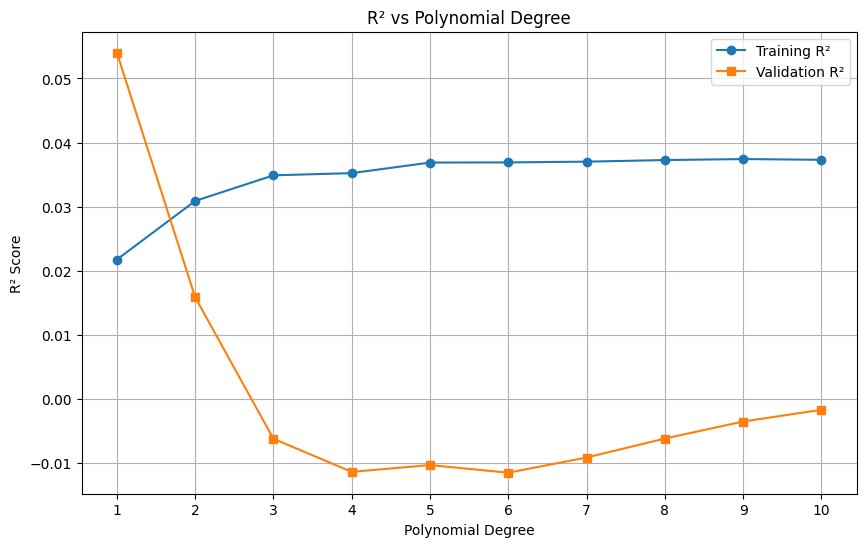

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_R2'],
    marker='o',
    label='Training R²'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_R2'],
    marker='s',
    label='Validation R²'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')

plt.title('R² vs Polynomial Degree')

plt.xticks(range(1, 11))

plt.legend()
plt.grid(True)

plt.show()

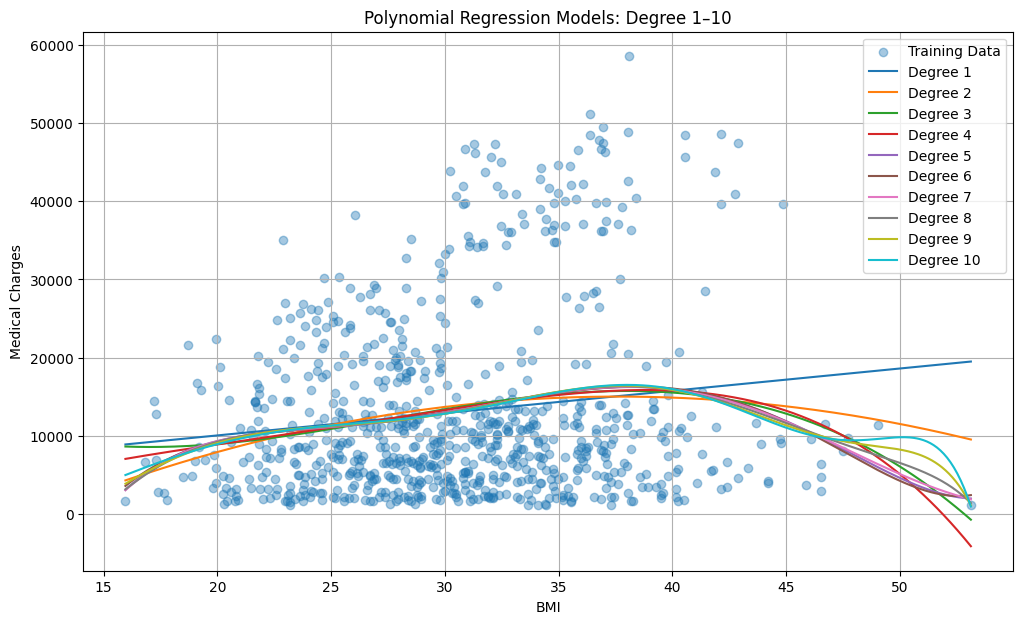

In [ ]:
X_plot = np.linspace(
    X['bmi'].min(),
    X['bmi'].max(),
    500
).reshape(-1, 1)

plt.figure(figsize=(12, 7))

plt.scatter(
    X_train,
    y_train,
    alpha=0.4,
    label='Training Data'
)

for degree in range(1, 11):

    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_plot = model.predict(X_plot)

    plt.plot(
        X_plot,
        y_plot,
        label=f'Degree {degree}'
    )

plt.xlabel('BMI')
plt.ylabel('Medical Charges')

plt.title('Polynomial Regression Models: Degree 1–10')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_test)

In [ ]:
linear_mse = mean_squared_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(linear_mse)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("LINEAR REGRESSION")
print("-----------------")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

LINEAR REGRESSION
-----------------
MSE: 150436624.90274242
RMSE: 12265.260898274542
MAE: 9186.718110988504
R²: 0.05046162422795619


In [ ]:
# Train the best polynomial regression model again

best_poly_model = make_pipeline(
    PolynomialFeatures(degree=best_degree),
    LinearRegression()
)

best_poly_model.fit(X_train, y_train)

# Predict on test data
best_poly_pred = best_poly_model.predict(X_test)

# Calculate metrics
best_poly_mse = mean_squared_error(y_test, best_poly_pred)
best_poly_rmse = np.sqrt(best_poly_mse)
best_poly_mae = mean_absolute_error(y_test, best_poly_pred)
best_poly_r2 = r2_score(y_test, best_poly_pred)

print("BEST POLYNOMIAL REGRESSION")
print("--------------------------")
print("Best Degree:", best_degree)
print("MSE:", best_poly_mse)
print("RMSE:", best_poly_rmse)
print("MAE:", best_poly_mae)
print("R²:", best_poly_r2)

BEST POLYNOMIAL REGRESSION
--------------------------
Best Degree: 1
MSE: 150436624.90274242
RMSE: 12265.260898274542
MAE: 9186.718110988504
R²: 0.05046162422795619


In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("LINEAR REGRESSION")
print("-----------------")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

LINEAR REGRESSION
-----------------
MSE: 150436624.90274242
RMSE: 12265.260898274542
MAE: 9186.718110988504
R²: 0.05046162422795619


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        f'Polynomial Regression (Degree {best_degree})'
    ],
    'MSE': [
        linear_mse,
        best_poly_mse
    ],
    'RMSE': [
        linear_rmse,
        best_poly_rmse
    ],
    'MAE': [
        linear_mae,
        best_poly_mae
    ],
    'R²': [
        linear_r2,
        best_poly_r2
    ]
})

comparison.round(4)

,Model,MSE,RMSE,MAE,R²
0,Linear Regression,1.504366e+08,12265.2609,9186.7181,0.0505
1,Polynomial Regression (Degree 1),1.504366e+08,12265.2609,9186.7181,0.0505


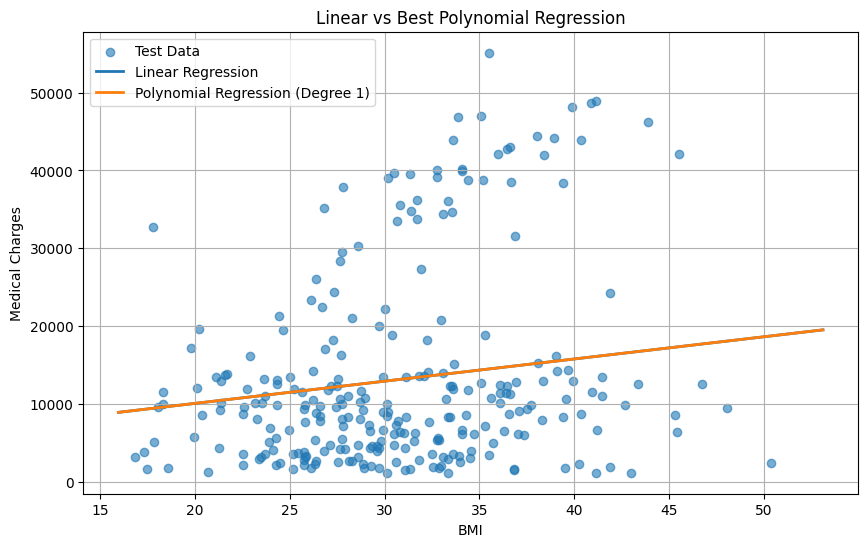

In [ ]:
linear_plot = linear_model.predict(X_plot)

poly_plot = best_poly_model.predict(X_plot)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.6,
    label='Test Data'
)

plt.plot(
    X_plot,
    linear_plot,
    linewidth=2,
    label='Linear Regression'
)

plt.plot(
    X_plot,
    poly_plot,
    linewidth=2,
    label=f'Polynomial Regression (Degree {best_degree})'
)

plt.xlabel('BMI')
plt.ylabel('Medical Charges')

plt.title('Linear vs Best Polynomial Regression')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("FINAL RESULTS FOR POLYNOMIAL REGRESSION")
print("=" * 80)

display(
    results_df.round(4)
)

FINAL RESULTS FOR POLYNOMIAL REGRESSION


,Degree,Train_MSE,Train_RMSE,Train_MAE,Train_R2,Validation_MSE,Validation_RMSE,Validation_MAE,Validation_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2
0,1,1.309553e+08,11443.5701,8839.8796,0.0217,1.629820e+08,12766.4406,9571.3693,0.0540,1.504366e+08,12265.2609,9186.7181,0.0505
1,2,1.297309e+08,11389.9466,8818.5196,0.0309,1.695570e+08,13021.4038,9760.8891,0.0159,1.506107e+08,12272.3564,9189.6946,0.0494
2,3,1.291953e+08,11366.4117,8829.3692,0.0349,1.733630e+08,13166.7373,9819.8964,-0.0062,1.485001e+08,12186.0618,9137.4242,0.0627
3,4,1.291495e+08,11364.3950,8824.5657,0.0352,1.742520e+08,13200.4536,9824.6961,-0.0114,1.484113e+08,12182.4186,9131.8562,0.0632
4,5,1.289285e+08,11354.6681,8812.7513,0.0369,1.740698e+08,13193.5504,9801.6004,-0.0103,1.483663e+08,12180.5688,9113.0091,0.0635
5,6,1.289254e+08,11354.5343,8811.7961,0.0369,1.742755e+08,13201.3452,9802.7851,-0.0115,1.484040e+08,12182.1169,9118.5606,0.0633
6,7,1.289096e+08,11353.8362,8811.2332,0.0370,1.738664e+08,13185.8403,9795.3306,-0.0092,1.484003e+08,12181.9657,9111.3277,0.0633
7,8,1.288763e+08,11352.3698,8806.3320,0.0373,1.733565e+08,13166.4927,9780.7566,-0.0062,1.485092e+08,12186.4331,9109.6599,0.0626
8,9,1.288556e+08,11351.4564,8798.9645,0.0374,1.728996e+08,13149.1276,9768.1954,-0.0035,1.486913e+08,12193.9033,9115.9232,0.0615
9,10,1.288706e+08,11352.1199,8792.9952,0.0373,1.725844e+08,13137.1386,9763.5081,-0.0017,1.488594e+08,12200.7946,9130.2609,0.0604


In [ ]:
results_df.round(4).to_csv(
    'medical_cost_polynomial_regression_results.csv',
    index=False
)

comparison.round(4).to_csv(
    'linear_vs_polynomial_comparison.csv',
    index=False
)

print("Result files created successfully!")

Result files created successfully!


In [ ]:
files.download(
    'medical_cost_polynomial_regression_results.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


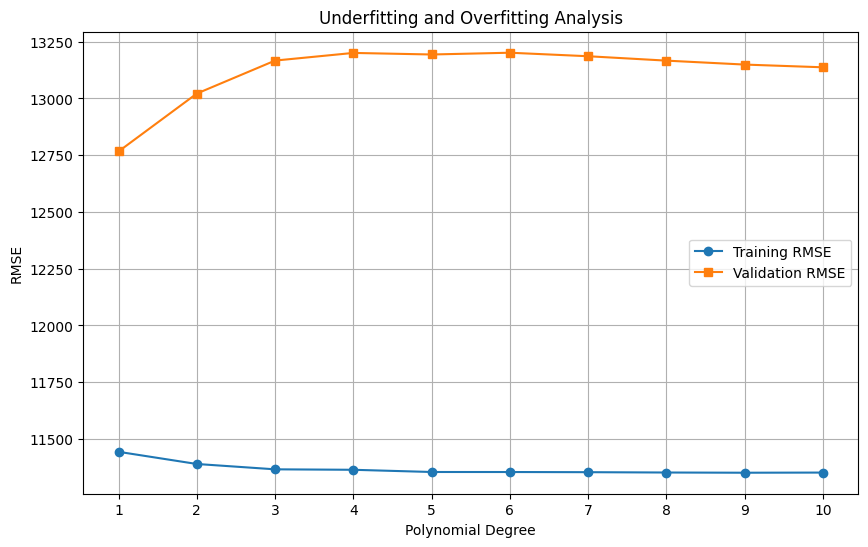

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df['Degree'],
    results_df['Train_RMSE'],
    marker='o',
    label='Training RMSE'
)

plt.plot(
    results_df['Degree'],
    results_df['Validation_RMSE'],
    marker='s',
    label='Validation RMSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Underfitting and Overfitting Analysis')

plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()